# CIFAR-10 批次文件按类别导出

这个 notebook 用 `click` 管理参数，把 `cifar-10-batches-py` 里的 batch 文件直接展开为 PNG 图片，并按类别目录保存，同时把运行日志写入 `CiFar10/Log` 下的日志文件。

## 1. 导入依赖与基础配置

导入 `pathlib`、`pickle`、`logging`、`click`、`PIL.Image`，并定义默认输入输出目录和日志目录。

In [7]:
from __future__ import annotations

import logging
import pickle
from pathlib import Path

import click
from PIL import Image

DEFAULT_INPUT_DIR = Path(r"d:/Jupyter Lab/CiFar10/cifar-10-batches-py")
DEFAULT_OUTPUT_DIR = Path(r"d:/Jupyter Lab/CiFar10/cifar-10-batches-py/export")
DEFAULT_LOG_DIR = Path(r"d:/Jupyter Lab/CiFar10/Log")
DEFAULT_LOG_NAME = "cifar10_export.log"
DEFAULT_PATTERN = "data_batch_*"
DEFAULT_INCLUDE_TEST = False


def setup_logging(log_dir: Path = DEFAULT_LOG_DIR, log_name: str = DEFAULT_LOG_NAME) -> logging.Logger:
    log_dir.mkdir(parents=True, exist_ok=True)
    logger = logging.getLogger("cifar10_export")
    logger.setLevel(logging.INFO)
    logger.propagate = False

    for handler in list(logger.handlers):
        logger.removeHandler(handler)
        handler.close()

    formatter = logging.Formatter("%(asctime)s %(levelname)s %(message)s")

    file_handler = logging.FileHandler(log_dir / log_name, encoding="utf-8")
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

    return logger


## 2. 读取 CIFAR-10 元数据

读取 `batches.meta`，解析类别名称，并统一兼容 `bytes` 与字符串键值。

In [2]:
def load_meta(meta_path: Path) -> list[str]:
    with meta_path.open("rb") as handle:
        data = pickle.load(handle, encoding="latin1")

    label_names = data.get(b"label_names") or data.get("label_names")
    if label_names is None:
        raise ValueError(f"Missing label_names in {meta_path}")

    return [name.decode("utf-8") if isinstance(name, bytes) else str(name) for name in label_names]


## 3. 加载批次文件并解析图像与标签

读取单个 CIFAR-10 batch，提取 `data`、`labels` 和 `filenames`。

In [3]:
def load_batch(batch_path: Path) -> dict:
    with batch_path.open("rb") as handle:
        return pickle.load(handle, encoding="latin1")


def unpack_batch(batch: dict) -> tuple:
    images = batch.get(b"data") or batch.get("data")
    labels = batch.get(b"labels") or batch.get("labels")
    filenames = batch.get(b"filenames") or batch.get("filenames")

    if images is None or labels is None or filenames is None:
        raise ValueError("Unexpected CIFAR batch format")

    return images, labels, filenames


## 4. 按类别导出 PNG 图片

把每张 $32\times 32$ 的 CIFAR-10 图像还原为 RGB 图像，并按类别目录保存为 PNG，同时记录处理进度到日志。

In [4]:
def export_batches_by_class(
    input_dir: Path,
    output_dir: Path,
    pattern: str = DEFAULT_PATTERN,
    include_test: bool = False,
    logger: logging.Logger | None = None,
) -> dict[str, int]:
    logger = logger or logging.getLogger("cifar10_export")
    class_names = load_meta(input_dir / "batches.meta")
    batch_paths = sorted(input_dir.glob(pattern))

    if include_test:
        test_batch = input_dir / "test_batch"
        if test_batch.exists() and test_batch not in batch_paths:
            batch_paths.append(test_batch)

    logger.info(
        "开始导出 CIFAR-10 图片: input_dir=%s output_dir=%s pattern=%s include_test=%s",
        input_dir,
        output_dir,
        pattern,
        include_test,
    )

    counts: dict[str, int] = {}

    for batch_path in batch_paths:
        logger.info("处理批次文件: %s", batch_path.name)
        batch = load_batch(batch_path)
        images, labels, filenames = unpack_batch(batch)

        for flat_image, label, filename in zip(images, labels, filenames):
            class_name = class_names[int(label)]
            class_dir = output_dir / class_name
            class_dir.mkdir(parents=True, exist_ok=True)

            image = flat_image.reshape(3, 32, 32).transpose(1, 2, 0)
            image_name = filename.decode("utf-8") if isinstance(filename, bytes) else str(filename)
            output_path = class_dir / f"{Path(image_name).stem}.png"
            Image.fromarray(image).save(output_path)
            counts[class_name] = counts.get(class_name, 0) + 1

    total = sum(counts.values())
    logger.info("导出完成，共写入 %s 张图片到 %s", total, output_dir)
    for class_name in sorted(counts):
        logger.info("%s: %s", class_name, counts[class_name])

    return counts


## 5. 使用 Click 定义命令行参数

使用 `click.command` 和 `click.option` 定义输入目录、输出目录、匹配模式和是否包含 `test_batch`，并在命令运行时初始化日志。

In [8]:
@click.command()
@click.option(
    "--input-dir",
    type=click.Path(path_type=Path, exists=True, file_okay=False, dir_okay=True),
    default=DEFAULT_INPUT_DIR,
    show_default=True,
    help="包含 batches.meta 和 batch 文件的目录。",
)
@click.option(
    "--output-dir",
    type=click.Path(path_type=Path, file_okay=False, dir_okay=True),
    default=DEFAULT_OUTPUT_DIR,
    show_default=True,
    help="导出 PNG 图片的目标目录。",
)
@click.option(
    "--pattern",
    type=str,
    default=DEFAULT_PATTERN,
    show_default=True,
    help="匹配要导出的 batch 文件模式。",
)
@click.option(
    "--include-test/--no-include-test",
    default=DEFAULT_INCLUDE_TEST,
    show_default=True,
    help="是否把 test_batch 一并导出。",
)
def main(input_dir: Path, output_dir: Path, pattern: str, include_test: bool) -> None:
    logger = setup_logging()
    export_batches_by_class(
        input_dir=input_dir,
        output_dir=output_dir,
        pattern=pattern,
        include_test=include_test,
        logger=logger,
    )

## 6. 在 Notebook 中运行导出流程并检查结果

在 Notebook 单元中直接调用导出函数，检查输出目录结构、文件数量、示例图片，以及 `CiFar10/Log` 下的日志文件是否生成。

2026-05-22 15:08:06,209 INFO 开始导出 CIFAR-10 图片: input_dir=d:\Jupyter Lab\CiFar10\cifar-10-batches-py output_dir=d:\Jupyter Lab\CiFar10\cifar-10-batches-py\export pattern=data_batch_* include_test=False
2026-05-22 15:08:06,209 INFO 处理批次文件: data_batch_1
2026-05-22 15:08:15,578 INFO 处理批次文件: data_batch_2
2026-05-22 15:08:24,676 INFO 处理批次文件: data_batch_3
2026-05-22 15:08:33,692 INFO 处理批次文件: data_batch_4
2026-05-22 15:08:42,676 INFO 处理批次文件: data_batch_5
2026-05-22 15:08:51,593 INFO 导出完成，共写入 50000 张图片到 d:\Jupyter Lab\CiFar10\cifar-10-batches-py\export
2026-05-22 15:08:51,593 INFO airplane: 5000
2026-05-22 15:08:51,593 INFO automobile: 5000
2026-05-22 15:08:51,593 INFO bird: 5000
2026-05-22 15:08:51,593 INFO cat: 5000
2026-05-22 15:08:51,605 INFO deer: 5000
2026-05-22 15:08:51,605 INFO dog: 5000
2026-05-22 15:08:51,605 INFO frog: 5000
2026-05-22 15:08:51,605 INFO horse: 5000
2026-05-22 15:08:51,605 INFO ship: 5000
2026-05-22 15:08:51,605 INFO truck: 5000


导出完成，共写入 50000 张图片
类别目录数量: 10
PNG 文件总数: 50000
日志文件: d:\Jupyter Lab\CiFar10\Log\cifar10_export.log
日志文件存在: True
前五个类别目录: ['airplane', 'automobile', 'bird', 'cat', 'deer']
最近日志:
2026-05-22 15:08:51,605 INFO dog: 5000
2026-05-22 15:08:51,605 INFO frog: 5000
2026-05-22 15:08:51,605 INFO horse: 5000
2026-05-22 15:08:51,605 INFO ship: 5000
2026-05-22 15:08:51,605 INFO truck: 5000

示例图片: d:\Jupyter Lab\CiFar10\cifar-10-batches-py\export\airplane\aeroplane_s_000004.png


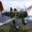

In [9]:
from IPython.display import display

logger = setup_logging()
output_dir = DEFAULT_OUTPUT_DIR
include_test = DEFAULT_INCLUDE_TEST
counts = export_batches_by_class(
    input_dir=DEFAULT_INPUT_DIR,
    output_dir=output_dir,
    pattern=DEFAULT_PATTERN,
    include_test=include_test,
    logger=logger,
)

total = sum(counts.values())
class_dirs = sorted([path for path in output_dir.iterdir() if path.is_dir()])
png_files = sorted(output_dir.rglob("*.png"))
log_file = DEFAULT_LOG_DIR / DEFAULT_LOG_NAME

print(f"导出完成，共写入 {total} 张图片")
print(f"类别目录数量: {len(class_dirs)}")
print(f"PNG 文件总数: {len(png_files)}")
print(f"日志文件: {log_file}")
print(f"日志文件存在: {log_file.exists()}")
print("前五个类别目录:", [path.name for path in class_dirs[:5]])

if log_file.exists():
    with log_file.open("r", encoding="utf-8") as handle:
        tail_lines = handle.readlines()[-5:]
    print("最近日志:")
    print("".join(tail_lines))

if png_files:
    sample_path = png_files[0]
    print(f"示例图片: {sample_path}")
    display(Image.open(sample_path))